## Modelado con Gaussian Mixture Model (GMM)


In [9]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import plotly.express as px
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')


In [10]:
df_clustering = pd.read_csv('df_clustering_models.csv')
df_nutrients = pd.read_csv('df_nutrients_models.csv')

df_clustering_pca = df_clustering.copy()
df_clustering_pca.drop(columns=['folio_integrante','edad', 'ponderador'], inplace=True)

pipeline = Pipeline([
    ('scaler', RobustScaler()),       
    ('pca', PCA(n_components=0.90))   
])

df_clustering_pca = pipeline.fit_transform(df_clustering_pca)

pca_model = pipeline.named_steps['pca']
print(f"Cantidad de componentes seleccionadas: {pca_model.n_components_}")
print(f"Porcentaje de varianza explicada: {pca_model.explained_variance_ratio_.sum() * 100:.2f}%")

df_clustering_pca = pd.DataFrame(df_clustering_pca, columns=[f"PC{i+1}" for i in range(pca_model.n_components_)])
df_clustering_pca.head()


Cantidad de componentes seleccionadas: 11
Porcentaje de varianza explicada: 90.66%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,-2.395293,0.219284,-0.714810,-0.494007,0.705281,0.538293,0.210961,0.731767,0.262595,-0.452635,-1.091718
1,0.668304,1.443943,-0.176644,-0.265166,0.205003,0.732128,0.193009,0.595354,0.183451,-0.082985,0.307179
2,-0.205455,-0.298500,2.430006,-0.166528,-0.957778,0.462324,0.082699,0.849533,-0.234574,0.448393,0.638345
3,8.574471,5.267610,1.355280,0.776853,-0.251853,-0.189998,2.500517,0.525608,1.626452,0.471267,-1.419893
4,0.923368,0.047328,-0.436197,1.921218,-1.984645,0.111165,0.308895,0.209951,0.282081,-0.477455,0.899421


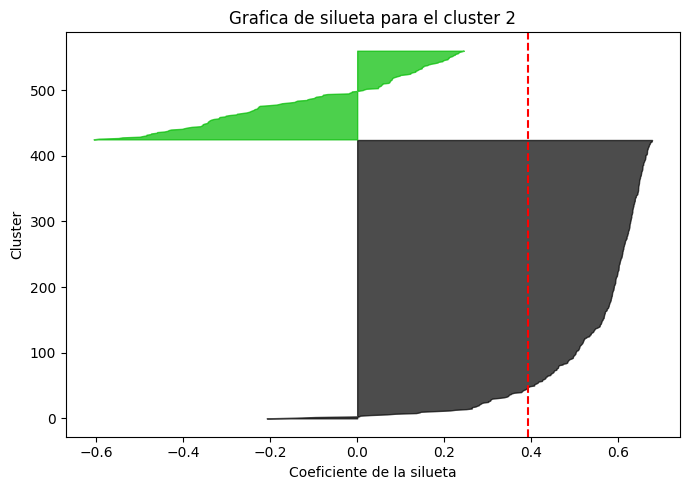

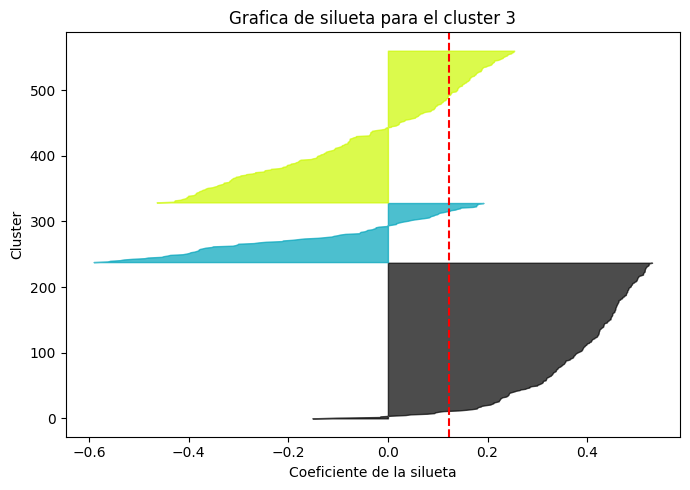

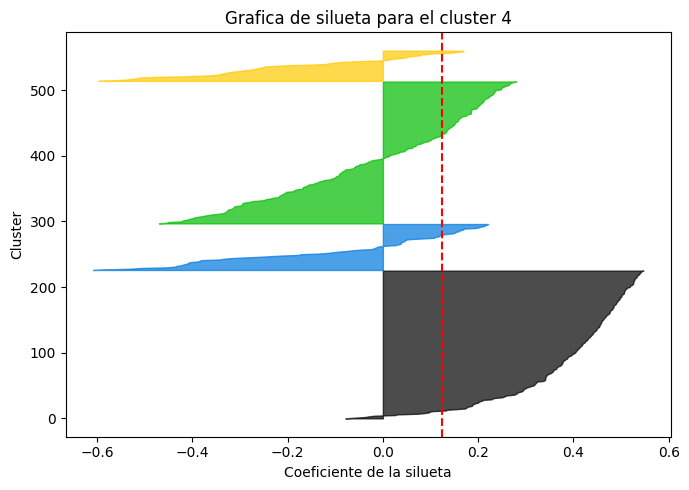

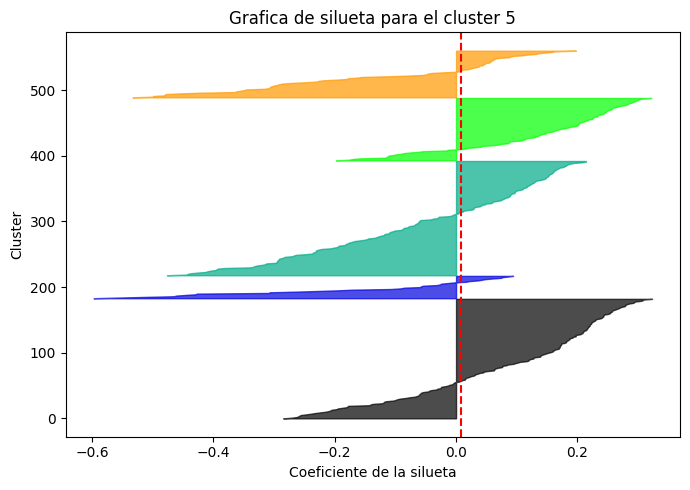

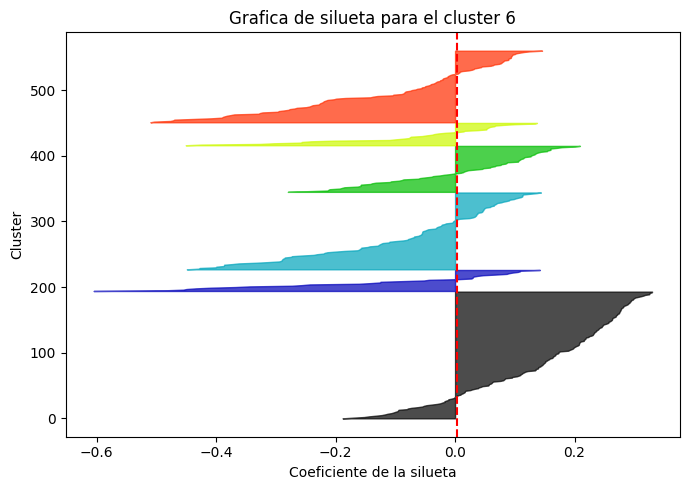

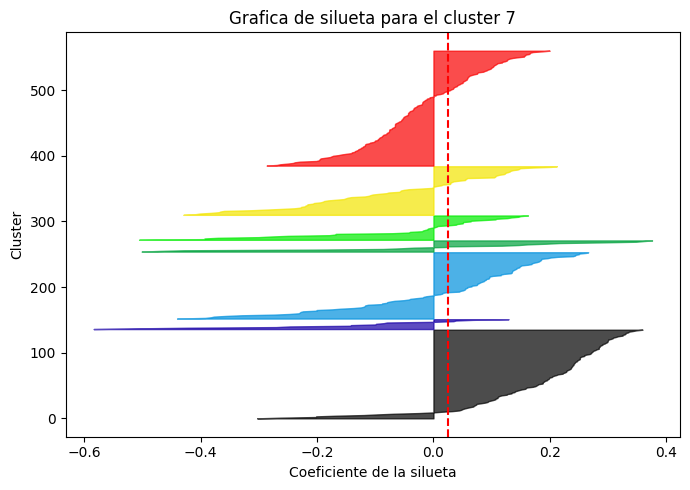

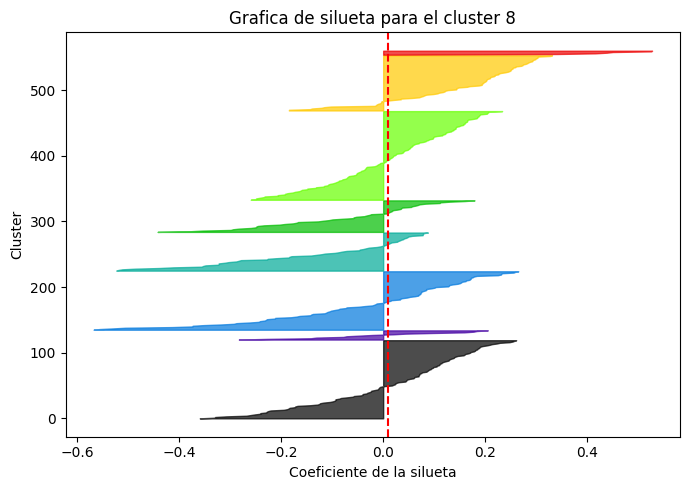

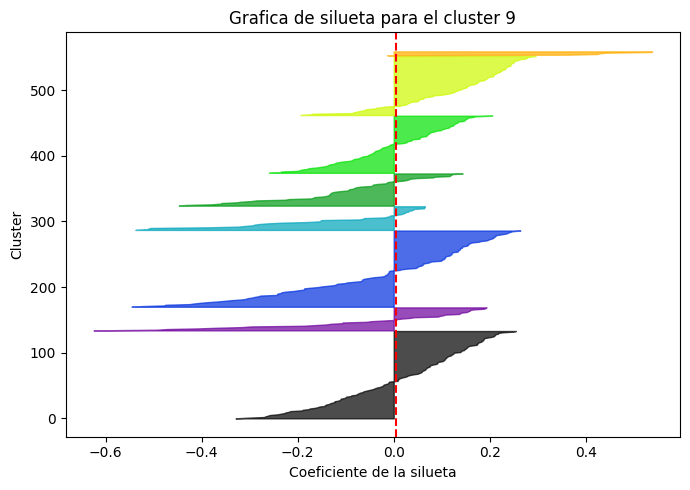

cluster = 2, Puntaje de Silueta = 0.3922501166497599
cluster = 3, Puntaje de Silueta = 0.1223307084332247
cluster = 4, Puntaje de Silueta = 0.12489471859530935
cluster = 5, Puntaje de Silueta = 0.00797949923244342
cluster = 6, Puntaje de Silueta = 0.0026999278766006098
cluster = 7, Puntaje de Silueta = 0.025540194343239085
cluster = 8, Puntaje de Silueta = 0.00969618607941387
cluster = 9, Puntaje de Silueta = 0.0038504434615836054


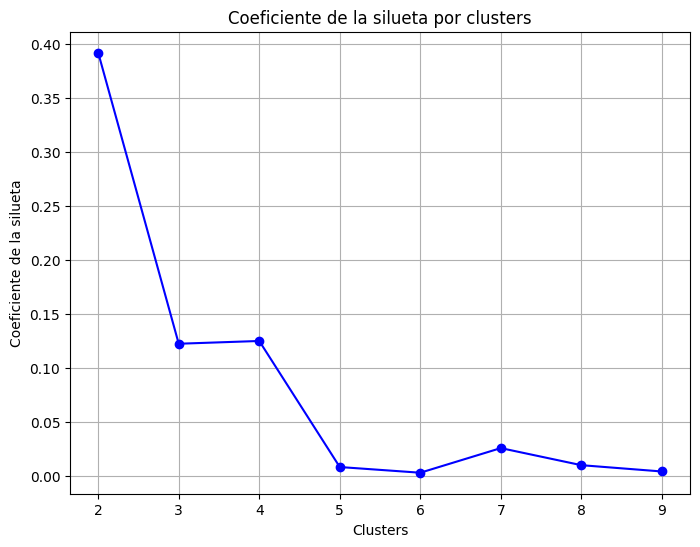

In [20]:
def gmm(X, clusters):
    silhouette_scores = []

    for cluster in clusters:
        gmm = GaussianMixture(n_components=cluster, random_state=42, max_iter=10000)
        gmm.fit(X)
        labels = gmm.predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
        plot_silhouette(X, labels, cluster)

    return silhouette_scores

def plot_silhouette(X, labels, cluster):
    silhouette_vals = silhouette_samples(X, labels)
    y_lower, y_upper = 0, 0
    n_clusters = np.unique(labels).shape[0]
    plt.figure(figsize=(7, 5))

    for i in range(n_clusters):
        ith_cluster_silhouette_values = silhouette_vals[labels == i]
        ith_cluster_silhouette_values.sort()
        y_upper += len(ith_cluster_silhouette_values)
        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper

    plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
    plt.title(f'Grafica de silueta para el cluster {cluster}')
    plt.xlabel('Coeficiente de la silueta')
    plt.ylabel('Cluster')
    plt.tight_layout()
    plt.show()

def plot_silhouette_vs_cluster(clusters, silhouette_scores):
    plt.figure(figsize=(8, 6))
    plt.plot(clusters, silhouette_scores, marker='o', linestyle='-', color='b')
    plt.title('Coeficiente de la silueta por clusters')
    plt.xlabel('Clusters')
    plt.ylabel('Coeficiente de la silueta')
    plt.grid(True)
    plt.show()

def plot_centroid_radar(centroides, cluster):
    num_features = centroides.shape[1]
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1] 

    plt.figure(figsize=(8, 8))
    
    for i in range(centroides.shape[0]):
        values = centroides[i].tolist()
        values += values[:1]  
        plt.subplot(1, 1, 1)
        plt.fill(angles, values, alpha=0.25)
        plt.plot(angles, values, label=f'Cluster {i + 1}')

    plt.xticks(angles[:-1], [f'Feature {i + 1}' for i in range(num_features)])
    plt.title(f'Grafica para cluster {cluster}')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_centroid_spider_plotly(centroides, cluster):
    num_features = centroides.shape[1]
    feature_labels = [f'Feature {i + 1}' for i in range(num_features)]

    data = []
    for i in range(cluster):
        values = centroides[i].tolist() + [centroides[i][0]]
        data.append(values)

    df = pd.DataFrame(data, columns=feature_labels + ['Feature 1'])
    df['Cluster'] = [f'Cluster {i + 1}' for i in range(cluster)]
    df = pd.melt(df, id_vars='Cluster', value_vars=feature_labels, var_name='Feature', value_name='Value')

    fig = px.line_polar(df, r='Value', theta='Feature', color='Cluster', line_close=True,
                        title=f'Spider Plot para cluster {cluster} ')

    fig.update_traces(fill='toself', opacity=0.25)
    fig.show()

clusters = range(2, 10)  

puntaje_de_silueta = gmm(df_clustering_pca, clusters)

for cluster, score in zip(clusters, puntaje_de_silueta):
    print(f'cluster = {cluster}, Puntaje de Silueta = {score}')

plot_silhouette_vs_cluster(clusters, puntaje_de_silueta)


In [16]:
df_nutrients.columns

Index(['energ_kcal', 'carbohydrt', 'lipid_tot', 'protein', 'fiber_td',
       'calcium', 'iron', 'ironhem', 'ironnohem', 'zinc', 'vit_c', 'thiamin',
       'riboflavin', 'niacin', 'panto_acid', 'vit_b6', 'folic_acid',
       'food_folate', 'folate_dfe', 'vit_b12', 'vit_a_rae', 'vit_e',
       'vit_d_iu', 'vit_k', 'fa_sat', 'fa_mono', 'fa_poly', 'chole',
       'carbohydrt_ratio', 'lipid_tot_ratio', 'protein_ratio',
       'macronutrients_dqi', 'poly_ratio', 'mono_ratio', 'fatty_acids_dqi',
       'balance_dqi', 'empty_calories_dqi', 'grasa_dqi', 'fa_sat_dqi',
       'colesterol_dqi', 'moderation_dqi'],
      dtype='object')

In [ ]:
# Con data frame de clustering

clusters = range(2, 10)  

puntaje_de_silueta = gmm(df_clustering, clusters)

for cluster, score in zip(clusters, puntaje_de_silueta):
    print(f'cluster = {cluster}, Puntaje de Silueta = {score}')

plot_silhouette_vs_cluster(clusters, puntaje_de_silueta)


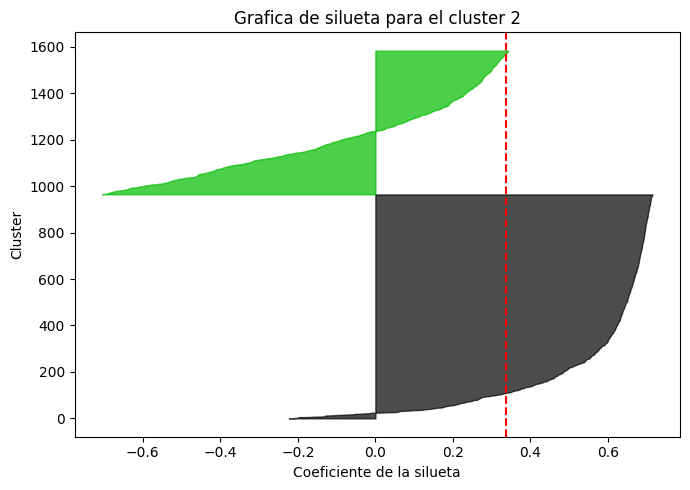

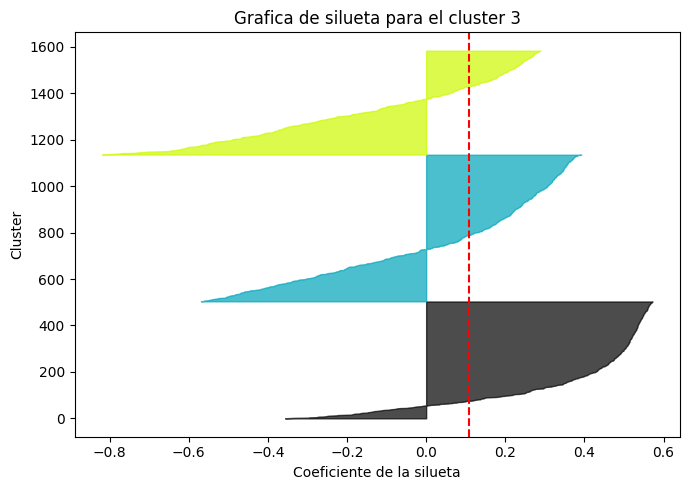

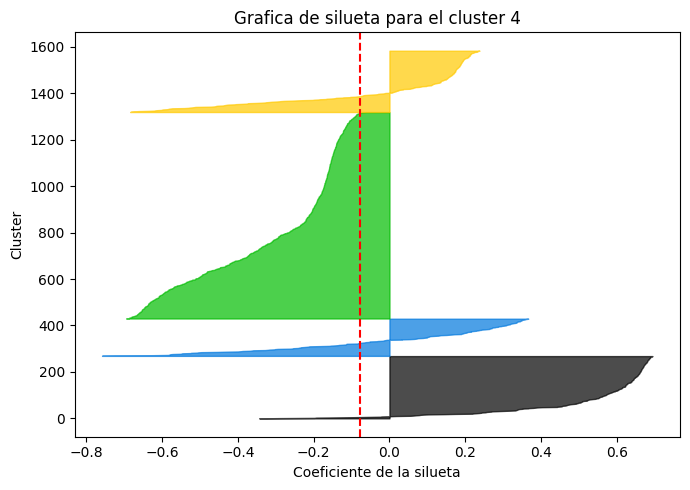

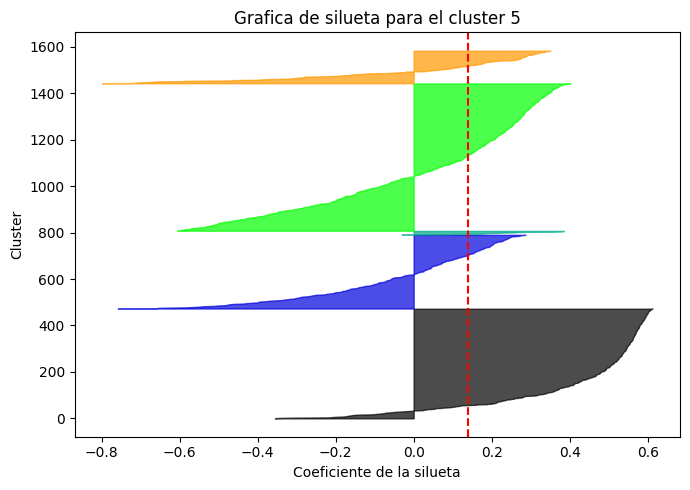

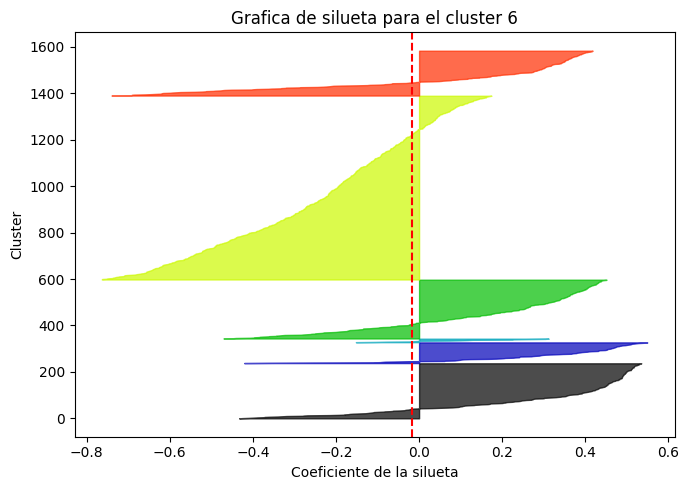

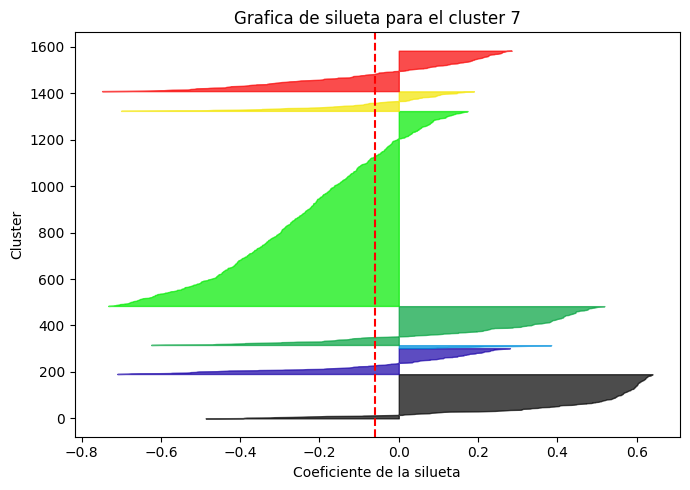

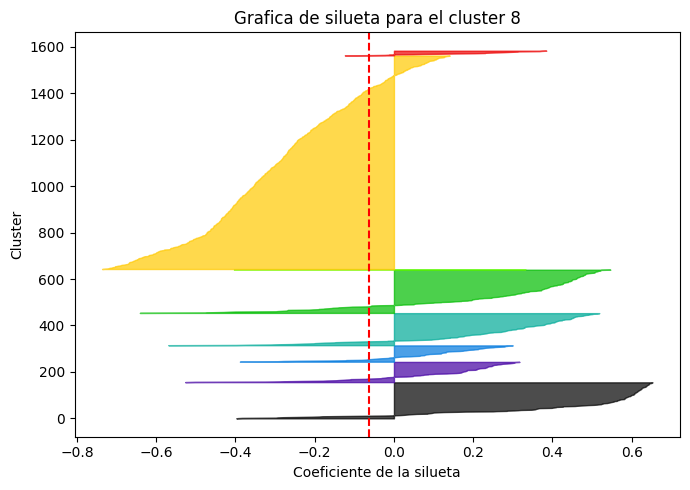

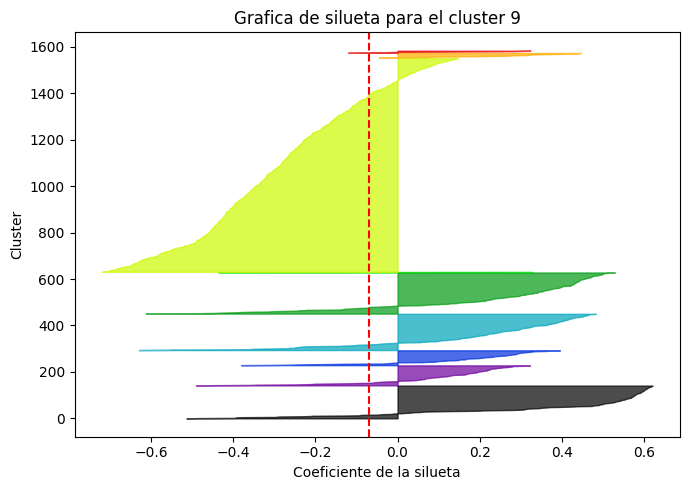

cluster = 2, Puntaje de Silueta = 0.3368494739990972
cluster = 3, Puntaje de Silueta = 0.1094382700296958
cluster = 4, Puntaje de Silueta = -0.07663647051224945
cluster = 5, Puntaje de Silueta = 0.13854781559601625
cluster = 6, Puntaje de Silueta = -0.018102406518567725
cluster = 7, Puntaje de Silueta = -0.06114806868571026
cluster = 8, Puntaje de Silueta = -0.06232616126441637
cluster = 9, Puntaje de Silueta = -0.06975894758314961


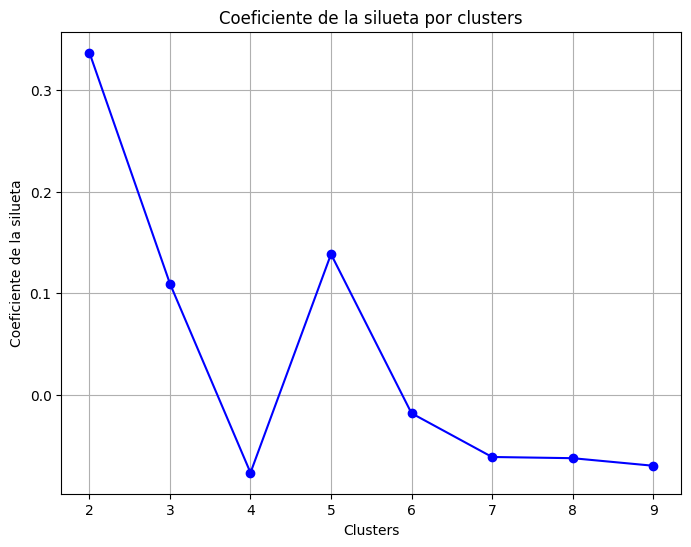

In [21]:
# Con data frame de nutrients

clusters = range(2, 10)  

puntaje_de_silueta = gmm(df_nutrients, clusters)

for cluster, score in zip(clusters, puntaje_de_silueta):
    print(f'cluster = {cluster}, Puntaje de Silueta = {score}')

plot_silhouette_vs_cluster(clusters, puntaje_de_silueta)
